<a href="https://colab.research.google.com/github/Rena03528/understanding_AI/blob/main/PyTorch_Workflow_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyTorch Workflow

what were covering:

* prepare and load data
* build a model
* fitting the model to data (training)
* making predictions and evaluating a model (inference)
* saving and loading a model
* putting al together

In [116]:
import torch
from torch import nn # nn contains all of PyTorch's building blocks for neural networks
import matplotlib. pyplot as plt

torch.__version__

'2.10.0+cpu'

## Data (preparing and loading)

Data can be almost anything... in machine learning.

* Excel speadsheet
* Images of any kind
* Videos
* Audio
* DNA
* Text

Machine Learning is a game of two parts:

1. Get data into a numerical representation.
2. Build a model to learn patterns in that numerical representation

To showcase this, let's create some known data using the linear regression formula.

We'll use a linear regression formula to make a straight line with known parameters.


In [117]:
# create known parameters
weight = 0.7
bias = 0.3

# Create
start = 0
end = 1
step= 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [118]:
len(X), len(y)

(50, 50)

### Splitting data into training and test sets

In [119]:
# Create a train/test split
train_split = int(0.8 * len(X)) # 80% of data used for training set, 20% for testing

X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

How might we better visualize our data?

This is where the data explorer's motto comes in!

"Visualize, visualize, visualize!"

In [120]:
def plot_predictions(train_data = X_train,
                     train_labels = y_train,
                     test_data = X_test,
                     test_label =y_test,
                     predictions = None):

  """
  Plots training data, test data and compare predictions.
  """

  plt.figure(figsize=(10, 7))

  #plot training data in blue
  plt.scatter(train_data,train_labels,c="b", s=4, label ="Training data")

  # plot testing data in green
  plt.scatter(test_data, test_label, c="g", s=4 , label = "Testing data")

  if predictions is not None:

    # plot the predictions in red if they exist
    plt.scatter(test_data, predictions, c="r", s=4, label ="Predictions")

  # Show the legend
  plt.legend(prop={"size":14});


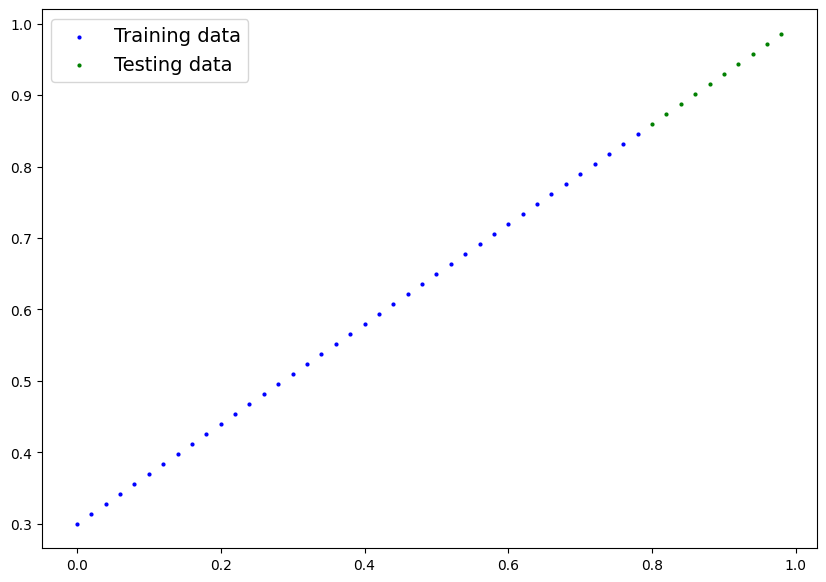

In [121]:
plot_predictions()

## 2. Build model

What our model does:
* Start with random values (weight & bias)
* Look at training data and adjust the random value to better represent ( or get closer to) the ideal value (the weight & bias values we used to create the data)

How does it do so?

Through two main algorithms:
1. **Gradient Descent**
2. **Backpropagation**

In [122]:
class LinearRegressionModel(nn.Module): # <- almost everything in Pytorch comes from nn
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1,
                                            requires_grad = True,
                                            dtype = torch.float))

    self.bias = nn.Parameter(torch.randn(1,
                                         requires_grad=True,
                                         dtype = torch.float))

    # Forward method to define the computation in the model
  def forward(self, x: torch.Tensor) -> torch.Tensor:
      return self.weights * x + self.bias

### PyTorch building essentials

* `torch.nn` - contains all of the buildings for computational graphs ( a neural network can be considered a computational graph)
* `torch.nn.Parameter` - what parameter should our model try and learn, often a Pytorch layer from torch.nn will set these for us
* `torch.nn.module` - The base class for all neural network modules, if you subclass it,, you should overwrite forward()
* `torch.opti` - this where optimizers in PyTorch live, they will help with gradient descent
* `def forward()` - All nn.Module subclasses require you to overwrite forward(), this method defines what happens in the forward computation

### Checking the contents of out PyTorch model

Now we've created a model, let's see what's inside...

So we can check our model parameters or what's inside our model using `.parametes()`

In [123]:
torch.manual_seed(42)

# create an instance of the model
model_0 = LinearRegressionModel()

# Check out the parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [124]:
# List named parametrs
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

# Making predicition using torch.`inference_mode()`

To check our models predictive power, let's see how well it predicts `y_test` based on `x_test`.

When we pass data trough our model, it's going to run it through the `forward()` method


In [125]:
# Making predicition with model

with torch.inference_mode():
  y_preds = model_0(X_test)

# YOu can also do something similar woth torch.no_grad(), however inference_mode() is prefered

y_preds


tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

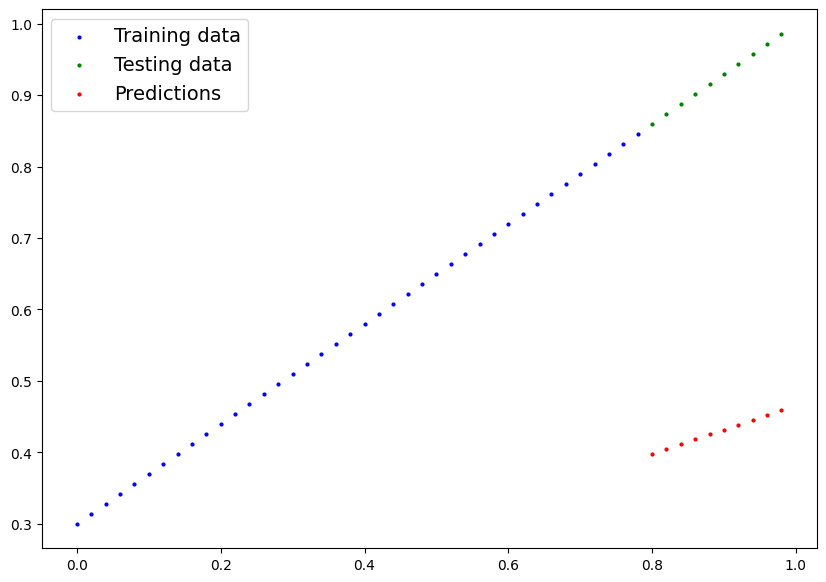

In [126]:
plot_predictions(predictions=y_preds)

### 3. Train Model

The whole idea of training is for a model to move from some unknown parameters to some known parameters

Or in other words from a poor representation of the data to a better representation of the data

One way to measure how poor or how wrong your models predictions are is to use a `loss function`

* Note: Loss function may also be called cost function or criterion in different areas.

We also need an optimizer. It takes into account the loss of a model and adjusts the model's parameters

And Specifically for PyTorch we need:

* Training Loop
* Testing Loop

In [127]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [128]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [129]:
# setup loss function
loss_fn = nn.L1Loss()
loss_fn

L1Loss()

In [130]:
# Setup an optimizer
optimizer = torch.optim.SGD(params = model_0.parameters(),lr = 0.01) # lr = learning rate

**Q**: Which loss function and optimizer should I use?
**A**: This will be problem specific. But with experience, you'll get an idea of what works and what doesn't with your particular problem set.

For example, for a regression problem like ours, a loss function on `nn.L1Loss` and an optimizer like torch.optim.SGD() will suffice.

But for a classification problem like classifying wether a photo is a dog or a cat, you'll likely want to use a loss function of `nn.BCELoss()` (binary cross entropy loss).

### Building a training loop (and a testing loop) in PyTorch

A couple of things we need in a training loop:
0. Loop trough the data
1. Forward pass this envolves envolve data moving trough our model's `forward()` functions - also called propagation.
2. Calculate the loss (compare forward pass predictions to ground truth labels)
3. Optimizer zero grad
4. Loss backward - move backwards trough the network to calculate the gradients of each the parameters of our model with respect to the loss.
5. Optimizer step - use the optimizer to adjust our model's parameters to try and improve the loss (**gradient descent**)

In [131]:
# an epoch is one loop trough the data...
epochs = 200

# Track different values
epoch_count = []
loss_values = []
test_loss_values = []

# 0. Loop trough the data
for epoch in range(epochs):
  # set the model to training mode
  model_0.train() # train mode in Pytorch set all the parameters that require gradient to require gradients

  # 1. forward pass
  y_pred = model_0(X_train)

  # 2. Calculate the loss
  loss = loss_fn(y_pred, y_train)

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Performa backpropagation on the loss with respect to the parameters of the model
  loss.backward()

  # 5. Step the optimizer (perform gradient descent)
  optimizer.step() # by default how the optimizer changes will accumulate trough the loop so... we ahve to zero them above in step 3 for the next iteration

  model_0.eval() # turns off gradient tracking

  with torch.inference_mode():
    # do the forward pass
    test_pred = model_0(X_test)

    # calculate the loss
    test_loss = loss_fn(test_pred, y_test)

  # Print out what's happening
  if epoch % 10 == 0:
    epoch_count.append(epoch)
    loss_values.append(loss)
    test_loss_values.append(test_loss)

    print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}")






Epoch: 0 | Loss: 0.31288138031959534 | Test loss: 0.48106518387794495
Epoch: 10 | Loss: 0.1976713240146637 | Test loss: 0.3463551998138428
Epoch: 20 | Loss: 0.08908725529909134 | Test loss: 0.21729660034179688
Epoch: 30 | Loss: 0.053148526698350906 | Test loss: 0.14464017748832703
Epoch: 40 | Loss: 0.04543796554207802 | Test loss: 0.11360953003168106
Epoch: 50 | Loss: 0.04167863354086876 | Test loss: 0.09919948130846024
Epoch: 60 | Loss: 0.03818932920694351 | Test loss: 0.08886633068323135
Epoch: 70 | Loss: 0.03476089984178543 | Test loss: 0.0805937647819519
Epoch: 80 | Loss: 0.03132382780313492 | Test loss: 0.07232122868299484
Epoch: 90 | Loss: 0.02788739837706089 | Test loss: 0.06473556160926819
Epoch: 100 | Loss: 0.024458957836031914 | Test loss: 0.05646304413676262
Epoch: 110 | Loss: 0.021020207554101944 | Test loss: 0.04819049686193466
Epoch: 120 | Loss: 0.01758546568453312 | Test loss: 0.04060482233762741
Epoch: 130 | Loss: 0.014155393466353416 | Test loss: 0.03233227878808975
Ep

In [132]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [133]:
with torch.inference_mode():
  y_preds_new = model_0(X_test)

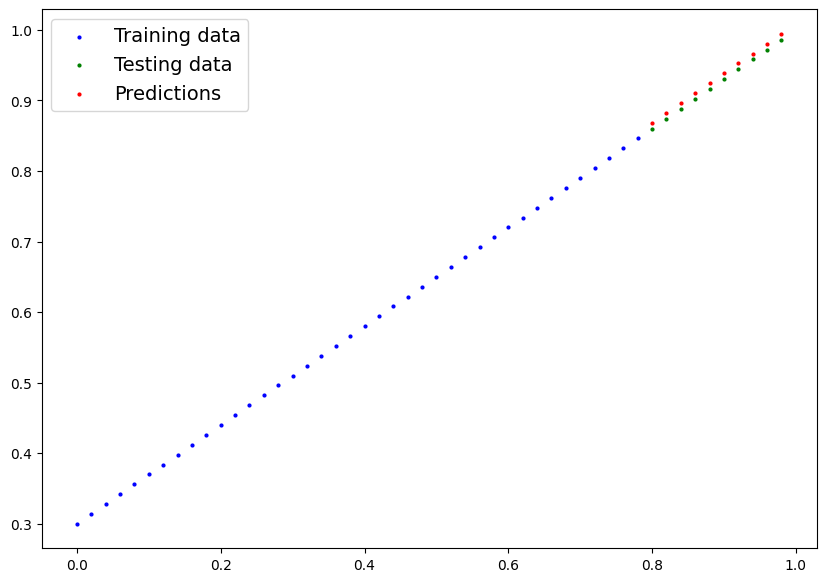

In [134]:
plot_predictions(predictions=y_preds_new)

In [135]:
import numpy as np

loss_values_np = np.array(torch.tensor(loss_values).numpy())

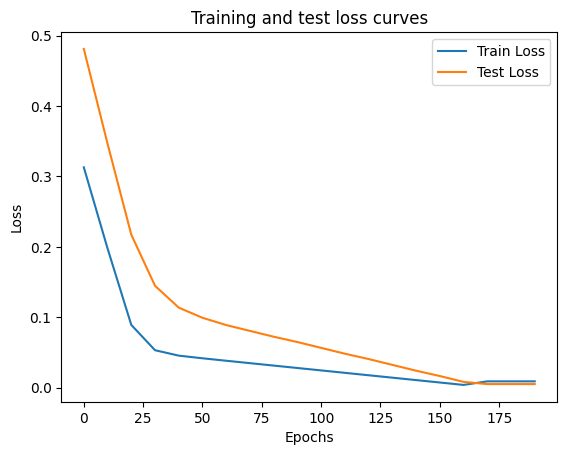

In [136]:
plt.plot(epoch_count, loss_values_np, label="Train Loss")
plt.plot(epoch_count, test_loss_values, label="Test Loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

### Saving a model in Pytorch

There a three main methods you should know about for saving and loading in Pytorch.

1. `torch.save()` - allows you to save a Pytorch object in Python pickle format
2. `torch.load()` - allows you to load a saver Pytorch object
3. `torch.nn.Module.load_state_dict()` - this allows to load a model's saved state dictionary

In [137]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])